# Feature Engineering: Techniques and Practice

Feature engineering is Step 4 of the ML workflow (Part I, slide 18): *"Encode categories, scale numbers, create informative derived columns."* It comes after cleaning (notebooks 02/04/05) and before modelling (notebook 03) -- the data here is already tidy, so this notebook can focus purely on turning good, clean columns into good, model-ready features.

**Part A (this notebook, worked example):** every technique demonstrated on `data/feature_engineering_demo.csv` -- a customer churn dataset with dates, categories of different kinds, and numeric columns on very different scales.

**Part B (practice, second half of this notebook):** a boilerplate section with a different dataset for you to engineer features on yourself.

**What we'll cover:**
1. One-hot encoding (unordered categories)
2. Ordinal encoding (ordered categories)
3. Scaling (StandardScaler vs. MinMaxScaler)
4. Date feature extraction
5. Derived / interaction features
6. Binning a continuous column
7. Putting it together: a full feature set ready for modelling

# Part A: Worked Example

## Setup and Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (7, 4.5)

print("Environment ready.")

Environment ready.


In [2]:
df = pd.read_csv("data/feature_engineering_demo.csv")
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded 300 rows x 10 columns


,customer_id,signup_date,age,monthly_income,city,education_level,membership_tier,num_purchases,last_purchase_date,churned
0,1,2023-01-01,39,9451.15,Davao,masters,silver,5,2023-03-26,0
1,2,2023-01-01,29,8501.46,Zamboanga,bachelors,bronze,6,2023-08-15,1
2,3,2023-01-02,63,8923.21,Manila,bachelors,silver,4,2024-02-20,0
3,4,2023-01-03,39,8475.88,Iloilo,masters,bronze,7,2023-03-11,1
4,5,2023-01-03,42,11141.52,Manila,bachelors,bronze,8,2023-05-26,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         300 non-null    int64  
 1   signup_date         300 non-null    str    
 2   age                 300 non-null    int64  
 3   monthly_income      300 non-null    float64
 4   city                300 non-null    str    
 5   education_level     300 non-null    str    
 6   membership_tier     300 non-null    str    
 7   num_purchases       300 non-null    int64  
 8   last_purchase_date  300 non-null    str    
 9   churned             300 non-null    int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 23.6 KB


This dataset (customer churn -- `churned`: did the customer leave) is already clean: no missing values, no duplicates, no leakage, nothing broken. It's a good candidate for feature engineering practice precisely *because* it's clean -- we can focus entirely on turning these raw columns into better model inputs, without cleaning noise getting in the way.

Six columns need work before this is model-ready:
- `signup_date`, `last_purchase_date` -- dates stored as text
- `city` -- an unordered category (no natural ranking between cities)
- `education_level`, `membership_tier` -- ordered categories (there's a real low-to-high ranking)
- `age`, `monthly_income` -- numeric, but on very different scales (tens vs. thousands)

## 1. Date Feature Extraction

A raw date string like `"2023-03-14"` is nearly useless to a model directly -- a model can't learn a meaningful pattern from a date treated as a category with hundreds of unique values. The real signal is usually in *derived* pieces: how long ago something happened, which month/day-of-week it fell on, or the gap between two dates.

First, convert to an actual datetime type (Part II, slide 23):

In [4]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"])
print(df[["signup_date", "last_purchase_date"]].dtypes)

signup_date           datetime64[us]
last_purchase_date    datetime64[us]
dtype: object


In [5]:
# Extract calendar pieces -- useful when behavior varies by season, month, or weekday
df["signup_month"] = df["signup_date"].dt.month
df["signup_dayofweek"] = df["signup_date"].dt.dayofweek  # 0=Monday

# Extract a DURATION between two dates -- often more useful than either raw date
df["days_since_signup"] = (pd.Timestamp.today() - df["signup_date"]).dt.days
df["days_since_last_purchase"] = (pd.Timestamp.today() - df["last_purchase_date"]).dt.days
df["customer_lifetime_days"] = (df["last_purchase_date"] - df["signup_date"]).dt.days

df[["signup_month", "signup_dayofweek", "days_since_signup", "days_since_last_purchase", "customer_lifetime_days"]].head()

,signup_month,signup_dayofweek,days_since_signup,days_since_last_purchase,customer_lifetime_days
0,1,6,1327,1243,84
1,1,6,1327,1101,226
2,1,0,1326,912,414
3,1,1,1325,1258,67
4,1,1,1325,1182,143


Now that we've pulled out the useful pieces, the raw date columns themselves aren't needed for modelling anymore -- drop them.

> **Watch out for `days_since_signup` on other datasets:** any "days since X" feature computed against *today's date* will silently change every time you re-run the notebook, weeks or months later. That's fine for exploration, but for a model going into production, this kind of feature needs a fixed, well-defined reference point (e.g. "the day this batch of data was pulled"), or it will behave inconsistently between training and deployment.

In [6]:
df = df.drop(columns=["signup_date", "last_purchase_date"])
print("Remaining columns:", list(df.columns))

Remaining columns: ['customer_id', 'age', 'monthly_income', 'city', 'education_level', 'membership_tier', 'num_purchases', 'churned', 'signup_month', 'signup_dayofweek', 'days_since_signup', 'days_since_last_purchase', 'customer_lifetime_days']


## 2. Ordinal Encoding (Ordered Categories)

`education_level` and `membership_tier` both have a real, natural ranking -- `high_school < bachelors < masters < phd`, and `bronze < silver < gold`. One-hot encoding these would throw that ordering away and treat every category as equally different from every other. **Ordinal encoding** maps each category to a number that preserves the order instead.

The key is telling the encoder the *correct* order explicitly -- if you let it guess (e.g. alphabetical), you'll get the wrong ranking.

In [7]:
education_order = ["high_school", "bachelors", "masters", "phd"]
tier_order = ["bronze", "silver", "gold"]

ordinal_encoder = OrdinalEncoder(categories=[education_order, tier_order])
df[["education_level", "membership_tier"]] = ordinal_encoder.fit_transform(
    df[["education_level", "membership_tier"]]
)

print("education_level: high_school=0, bachelors=1, masters=2, phd=3")
print("membership_tier: bronze=0, silver=1, gold=2")
df[["education_level", "membership_tier"]].head()

education_level: high_school=0, bachelors=1, masters=2, phd=3
membership_tier: bronze=0, silver=1, gold=2


,education_level,membership_tier
0,2.0,1.0
1,1.0,0.0
2,1.0,1.0
3,2.0,0.0
4,1.0,0.0


## 3. One-Hot Encoding (Unordered Categories)

`city` has no natural ranking -- Manila isn't "more" or "less" than Cebu in any numeric sense. Assigning them arbitrary numbers (0, 1, 2...) like ordinal encoding does would invent a false ordering and a false distance between categories that a model might mistakenly learn from. **One-hot encoding** avoids this by creating one 0/1 column per category instead.

In [8]:
print("city categories:", df["city"].nunique())
print(df["city"].value_counts())

df = pd.get_dummies(df, columns=["city"], drop_first=True)
print("\nNew columns added:", [c for c in df.columns if c.startswith("city_")])

city categories: 7
city
Manila            102
Cebu               73
Davao              44
Baguio             28
Zamboanga          23
Iloilo             16
Cagayan de Oro     14
Name: count, dtype: int64

New columns added: ['city_Cagayan de Oro', 'city_Cebu', 'city_Davao', 'city_Iloilo', 'city_Manila', 'city_Zamboanga']


> **Watch out for high cardinality on other datasets:** with only 7 cities, `get_dummies` adds a manageable 6 new columns. But a column like `"zip_code"` or `"product_id"` might have hundreds or thousands of unique values -- one-hot encoding that directly creates hundreds of mostly-empty columns, which hurts both performance and model quality. Common fixes: group rare categories into an `"other"` bucket first (e.g. keep the top 20 cities, lump the rest together), or use a different encoding scheme like frequency encoding (replace each category with how often it appears) or target encoding (replace each category with the average target value for that category -- powerful, but has to be done carefully to avoid leaking target information, so it's only fit on training data, same as a scaler).

## 4. Binning a Continuous Column

Sometimes a continuous number is more useful to a model as a smaller set of groups -- especially when you suspect the relationship isn't smoothly linear (e.g. "young adults" and "seniors" might behave similarly to each other but differently from "middle-aged," rather than churn risk rising steadily with every single year of age). `pd.cut` turns a numeric column into named bins.

This is optional -- keeping `age` as a raw number is often fine too, and tree-based models (like the `RandomForest` used in notebook 03) can already find non-linear splits on their own. Binning is more valuable for linear models, or when you want an interpretable, human-readable grouping.

age_group
18-25    36
26-40    92
41-55    79
56+      93
Name: count, dtype: int64


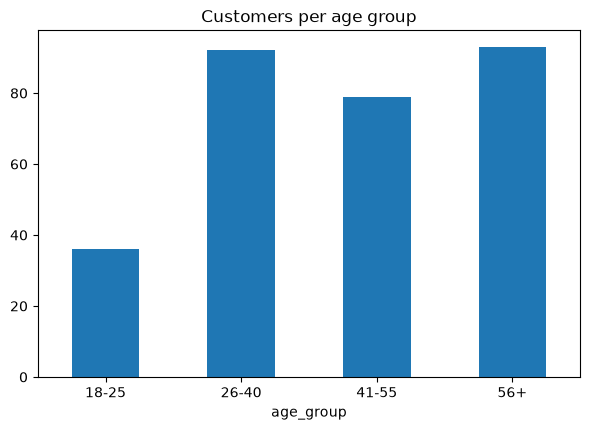

In [9]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 55, 100],
    labels=["18-25", "26-40", "41-55", "56+"],
)

print(df["age_group"].value_counts().sort_index())

fig, ax = plt.subplots()
df["age_group"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Customers per age group")
plt.xticks(rotation=0)
plt.show()

# age_group is a new ordered category -- encode it the same way as Step 2
df["age_group"] = OrdinalEncoder(categories=[["18-25", "26-40", "41-55", "56+"]]).fit_transform(
    df[["age_group"]]
)

## 5. Derived and Interaction Features

Sometimes the most useful signal isn't in any single raw column, but in a *combination* of columns. This is the "create informative derived columns" part of Part I slide 18 -- and it's the part of feature engineering that benefits most from actually understanding the problem, not just running a technique.

A couple of derived features that make business sense for a churn dataset:

In [10]:
# Purchases per day since signup -- captures "purchase rate" better than either
# raw column alone. A customer with 20 purchases over 2 years is very different
# from one with 20 purchases over 2 months, even though num_purchases is the same.
df["purchases_per_day"] = df["num_purchases"] / df["days_since_signup"].clip(lower=1)

# Days since last purchase relative to the customer's whole lifetime as a customer --
# a customer inactive for 100 days after only 120 days as a customer is a much
# stronger churn signal than 100 days of inactivity for a 3-year customer.
df["inactivity_ratio"] = df["days_since_last_purchase"] / df["days_since_signup"].clip(lower=1)

df[["num_purchases", "days_since_signup", "purchases_per_day",
    "days_since_last_purchase", "inactivity_ratio"]].head()

,num_purchases,days_since_signup,purchases_per_day,days_since_last_purchase,inactivity_ratio
0,5,1327,0.003768,1243,0.936699
1,6,1327,0.004521,1101,0.829691
2,4,1326,0.003017,912,0.687783
3,7,1325,0.005283,1258,0.949434
4,8,1325,0.006038,1182,0.892075


> **Watch out for derived features on other datasets:** the risk isn't technical, it's conceptual -- it's easy to accidentally build a derived feature that recreates the leakage problem from notebook 04, if the columns you combine include something only known after the target outcome. Ask the same leakage question again for every new derived column, not just the original ones. Also watch for divide-by-zero when a denominator column can be 0 (handled above with `.clip(lower=1)`).

## 6. Scaling

Look at the range of `age` (18-70) versus `monthly_income` (1,500-12,000). Without scaling, a model that's sensitive to feature magnitude (like logistic regression, or anything using distance) would let `monthly_income` dominate purely because its numbers are bigger -- not because it's actually more important. Part II slide 20 covers this rule: **fit the scaler on training data only**, then apply it to both train and test. This demo scales the whole dataset just to show the *technique* -- notebook 03 shows the correct split-then-scale order for an actual modelling pipeline.

Two common scalers, and when to reach for each:

Before scaling:
            age  monthly_income
min   18.000000     1505.600000
max   69.000000    11999.290000
mean  44.416667     6676.193200
std   14.861334     2989.047472


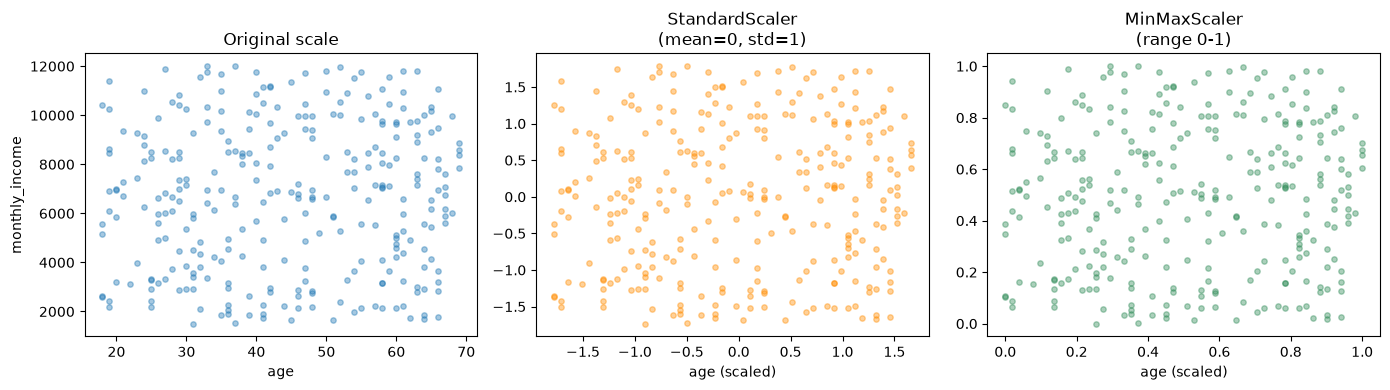

In [11]:
print("Before scaling:")
print(df[["age", "monthly_income"]].describe().loc[["min", "max", "mean", "std"]])

standard_scaled = StandardScaler().fit_transform(df[["age", "monthly_income"]])
minmax_scaled = MinMaxScaler().fit_transform(df[["age", "monthly_income"]])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(df["age"], df["monthly_income"], alpha=0.4, s=15)
axes[0].set_title("Original scale")
axes[0].set_xlabel("age")
axes[0].set_ylabel("monthly_income")

axes[1].scatter(standard_scaled[:, 0], standard_scaled[:, 1], alpha=0.4, s=15, color="darkorange")
axes[1].set_title("StandardScaler\n(mean=0, std=1)")
axes[1].set_xlabel("age (scaled)")

axes[2].scatter(minmax_scaled[:, 0], minmax_scaled[:, 1], alpha=0.4, s=15, color="seagreen")
axes[2].set_title("MinMaxScaler\n(range 0-1)")
axes[2].set_xlabel("age (scaled)")

plt.tight_layout()
plt.show()

Notice the *shape* of the scatter plot doesn't change between the three -- scaling never changes the relationship between points, only the numbers on the axes.

- **StandardScaler** (mean 0, std 1): the safer general-purpose default. Handles outliers reasonably and works well for most algorithms (logistic regression, SVMs, neural networks).
- **MinMaxScaler** (fixed 0-1 range): useful when an algorithm needs bounded input (some neural network setups), or when you want scaled values to stay interpretable as "0% to 100% of the observed range." More sensitive to outliers -- one extreme value compresses everything else toward 0.

> **Watch out for scaling on other datasets:** tree-based models (`RandomForestClassifier`, `DecisionTreeClassifier`, gradient boosting) don't actually need scaling at all -- they split on thresholds, not distances, so scale doesn't affect them. Scaling those anyway isn't harmful, just unnecessary. It matters most for distance-based or gradient-based algorithms: logistic regression, SVMs, k-nearest neighbors, neural networks, and anything using PCA.

Apply the scaler for real now:

In [12]:
numeric_cols_to_scale = [
    "age", "monthly_income", "num_purchases", "days_since_signup",
    "days_since_last_purchase", "customer_lifetime_days",
    "purchases_per_day", "inactivity_ratio",
]
scaler = StandardScaler()
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

df[numeric_cols_to_scale].describe().loc[["mean", "std"]].round(2)

,age,monthly_income,num_purchases,days_since_signup,days_since_last_purchase,customer_lifetime_days,purchases_per_day,inactivity_ratio
mean,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. Putting It Together

Here's the final, fully engineered feature set -- every column is now numeric, on comparable scales, and includes both the original signal and the derived features we built on top of it.

In [13]:
print(f"Final shape: {df.shape}")
print(f"All numeric: {(df.dtypes != 'object').all()}")
print(f"\nFinal columns:\n{list(df.columns)}")
df.head()

Final shape: (300, 21)
All numeric: True

Final columns:
['customer_id', 'age', 'monthly_income', 'education_level', 'membership_tier', 'num_purchases', 'churned', 'signup_month', 'signup_dayofweek', 'days_since_signup', 'days_since_last_purchase', 'customer_lifetime_days', 'city_Cagayan de Oro', 'city_Cebu', 'city_Davao', 'city_Iloilo', 'city_Manila', 'city_Zamboanga', 'age_group', 'purchases_per_day', 'inactivity_ratio']


,customer_id,age,monthly_income,education_level,membership_tier,num_purchases,churned,signup_month,signup_dayofweek,days_since_signup,days_since_last_purchase,customer_lifetime_days,city_Cagayan de Oro,city_Cebu,city_Davao,city_Iloilo,city_Manila,city_Zamboanga,age_group,purchases_per_day,inactivity_ratio
0,1,-0.365090,0.929926,2.0,1.0,-0.298199,0,1,6,1.718493,1.686082,-1.115417,False,False,True,False,False,False,1.0,-0.467523,1.152451
1,2,-1.039101,0.611672,1.0,0.0,0.131896,1,1,6,1.718493,0.794573,-0.144558,False,False,False,False,False,True,1.0,-0.077650,0.269196
2,3,1.252538,0.753006,1.0,1.0,-0.728293,0,1,0,1.702191,-0.392013,1.140806,False,False,False,False,True,False,3.0,-0.856220,-0.902126
3,4,-0.365090,0.603100,2.0,0.0,0.561990,1,1,1,1.685889,1.780256,-1.231647,False,False,False,True,False,False,1.0,0.316343,1.257564
4,5,-0.162886,1.496392,1.0,0.0,0.992084,0,1,1,1.685889,1.303110,-0.712032,False,False,False,False,True,False,2.0,0.706805,0.784122


### Summary

| # | Technique | Applied to | Why |
|---|---|---|---|
| 1 | Date extraction | `signup_date`, `last_purchase_date` | Turned two dates into 5 useful numeric signals (month, weekday, durations) |
| 2 | Ordinal encoding | `education_level`, `membership_tier` | Preserves the real low-to-high ranking these categories have |
| 3 | One-hot encoding | `city` | No natural order between cities -- one 0/1 column per category |
| 4 | Binning | `age` -> `age_group` | Groups age into interpretable buckets (optional; trees don't need this) |
| 5 | Derived features | `purchases_per_day`, `inactivity_ratio` | Combines two columns into a signal neither carries alone |
| 6 | Scaling | All numeric columns | Puts `age` and `monthly_income` on comparable ranges |

This feature set is now ready for `train_test_split` and modelling (notebook 03) -- though remember, in a real pipeline the scaler (and any encoder using target information) should be **fit on the training split only**, not the whole dataset like we did here for demonstration.

**Your turn:** Part B below has a different, unscaled dataset with its own set of categorical, date, and numeric columns. Work through the same techniques yourself.

# Part B: Your Turn

**The dataset:** `data/feature_engineering_practice.csv` -- a movie streaming subscriber dataset (`cancelled`: did the subscriber cancel). Like Part A's dataset, it's already clean (no missing values, duplicates, or leakage to worry about) -- this is purely feature engineering practice.

Columns that need work:
- `join_date`, `last_active_date` -- dates stored as text
- `country` -- an unordered category
- `plan_tier`, `device_rating` -- ordered categories (figure out the right order for each)
- `age`, `monthly_fee`, `shows_watched`, `avg_session_minutes` -- numeric, different scales

Apply the same six techniques from Part A, in the same order (order matters less here than in cleaning, but doing dates first and scaling last, after all other numeric columns exist, tends to avoid rework).

In [14]:
df2 = pd.read_csv("data/feature_engineering_practice.csv")
print(f"Loaded {df2.shape[0]} rows x {df2.shape[1]} columns")
df2.head()

Loaded 280 rows x 11 columns


,user_id,join_date,last_active_date,age,monthly_fee,country,plan_tier,device_rating,shows_watched,avg_session_minutes,cancelled
0,1,2022-06-01,2024-03-09,60,11.61,USA,premium,good,16,50.1,0
1,2,2022-06-01,2023-01-06,61,8.15,Philippines,basic,fair,18,141.7,0
2,3,2022-06-01,2023-07-18,18,15.31,Canada,standard,fair,14,156.1,1
3,4,2022-06-02,2023-04-20,35,10.70,Philippines,standard,fair,17,121.1,1
4,5,2022-06-02,2023-11-30,67,16.55,Philippines,basic,excellent,14,102.7,1


## 1. Date Feature Extraction

Convert `join_date` and `last_active_date` to real datetimes, then derive at least: a duration since joining, a duration since last active, and how long the gap is between the two dates. Drop the raw date columns once you've extracted what you need.

In [15]:
# TODO: convert join_date and last_active_date to datetime with pd.to_datetime().


In [16]:
# TODO: derive at least 2-3 duration columns (days_since_join, days_since_active,
# membership_length_days, etc.), then drop the raw date columns.
# Hint (same pattern as Part A):
# df2["days_since_join"] = (pd.Timestamp.today() - df2["join_date"]).dt.days


## 2. Ordinal Encoding

Both `plan_tier` and `device_rating` have a natural order. Work out what the correct order is for each (read the actual category values with `df2["plan_tier"].unique()` if you're not sure), then use `OrdinalEncoder` with an explicit `categories=` list -- don't let it guess.

In [17]:
# TODO: check the actual category values first.
# print(df2["plan_tier"].unique())
# print(df2["device_rating"].unique())


In [18]:
# TODO: ordinal-encode plan_tier and device_rating with the correct order.
# Hint (same pattern as Part A):
# plan_order = [...]
# device_order = [...]
# encoder = OrdinalEncoder(categories=[plan_order, device_order])
# df2[["plan_tier", "device_rating"]] = encoder.fit_transform(df2[["plan_tier", "device_rating"]])


## 3. One-Hot Encoding

`country` has no natural order. One-hot encode it. (Check `df2["country"].nunique()` first -- with 8 countries this is a manageable case, but it's worth noticing whether it *would* need the high-cardinality treatment mentioned in Part A.)

In [19]:
# TODO: one-hot encode country.
# Hint: df2 = pd.get_dummies(df2, columns=["country"], drop_first=True)


## 4. Binning (Optional)

Try binning `age` into groups the way Part A did, then ordinal-encode the resulting bins. This step is optional -- skip it if you'd rather keep `age` as a raw number.

In [20]:
# TODO (optional): bin age into groups with pd.cut(), then ordinal-encode the bins.


## 5. Derived Features

Build at least one derived feature that combines two existing columns into something neither carries alone. Some ideas for this dataset (pick one, or invent your own): a "watch rate" combining `shows_watched` and the days since joining, or an engagement measure combining `avg_session_minutes` and `shows_watched`. Remember the leakage question -- would you actually know this at prediction time?

In [21]:
# TODO: create at least one derived feature.
# Hint: watch out for divide-by-zero -- use .clip(lower=1) on any denominator column.


## 6. Scaling

Scale the numeric columns with `StandardScaler`. List out which columns are numeric first (`df2.select_dtypes(include=np.number).columns`), decide whether `user_id` and `cancelled` (the target) belong in that list (they don't -- an ID isn't a feature, and you never scale the target), then scale the rest.

In [22]:
# TODO: scale the numeric feature columns (not user_id, not cancelled).
# Hint (same pattern as Part A):
# cols_to_scale = [c for c in df2.select_dtypes(include=np.number).columns
#                   if c not in ("user_id", "cancelled")]
# df2[cols_to_scale] = StandardScaler().fit_transform(df2[cols_to_scale])


## Final Check: Self-Grading Cell

Run this last.

In [23]:
checks = []

has_text_cols = len(df2.select_dtypes(include="object").columns) > 0
checks.append(("No text/categorical columns remain unencoded", not has_text_cols,
               f"still text: {list(df2.select_dtypes(include='object').columns)}" if has_text_cols else "all encoded"))

no_raw_dates = ("join_date" not in df2.columns) and ("last_active_date" not in df2.columns)
checks.append(("Raw date columns dropped", no_raw_dates,
               "join_date/last_active_date still present" if not no_raw_dates else "dropped"))

has_duration_feature = any(
    "day" in c.lower() or "since" in c.lower() or "length" in c.lower() for c in df2.columns
)
checks.append(("At least one derived duration feature exists", has_duration_feature,
               "no obvious duration column found -- did you derive one from the dates?" if not has_duration_feature else "found"))

feature_cols = [c for c in df2.columns if c not in ("user_id", "cancelled")]
numeric_feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df2[c])]
looks_scaled = all(
    abs(df2[c].mean()) < 0.5 and 0.5 < df2[c].std() < 2.0
    for c in numeric_feature_cols if df2[c].nunique() > 2  # skip 0/1 dummy columns
) if numeric_feature_cols else False
checks.append(("Numeric features look scaled (mean~0, std~1)", looks_scaled,
               "check your StandardScaler step" if not looks_scaled else "looks right"))

print(f"{'CHECK':50s} {'RESULT':8s} DETAIL")
print("-" * 95)
for name, ok, detail in checks:
    print(f"{name:50s} {'PASS' if ok else 'FAIL':8s} {detail}")

passed = sum(1 for _, ok, _ in checks if ok)
print("-" * 95)
print(f"Score: {passed}/{len(checks)}")
if passed == len(checks):
    print("\nAll checks passed -- this feature set is ready for modelling")
    print("(see 03_modelling_template.ipynb for the next step).")
else:
    print("\nSome checks failed -- go back to the matching section above and try again.")

CHECK                                              RESULT   DETAIL
-----------------------------------------------------------------------------------------------
No text/categorical columns remain unencoded       FAIL     still text: ['join_date', 'last_active_date', 'country', 'plan_tier', 'device_rating']
Raw date columns dropped                           FAIL     join_date/last_active_date still present
At least one derived duration feature exists       FAIL     no obvious duration column found -- did you derive one from the dates?
Numeric features look scaled (mean~0, std~1)       FAIL     check your StandardScaler step
-----------------------------------------------------------------------------------------------
Score: 0/4

Some checks failed -- go back to the matching section above and try again.


/var/folders/ly/7pk4symd71x4t2ms4xq2py_h0000gn/T/ipykernel_22288/1713039717.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  has_text_cols = len(df2.select_dtypes(include="object").columns) > 0
/var/folders/ly/7pk4symd71x4t2ms4xq2py_h0000gn/T/ipykernel_22288/1713039717.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
Se